# Wrangling and Summarizing Data

Read this notebook from top to bottom and fill in the code as you go. Work together and discuss with other students in the class. Try to resolve any errors on your own first, but don't get stuck; ask for help!

In addition to writing and running code, be sure to examine any output and interpret the results before moving on.

For many of these questions, there are several ways to do it in Pandas. You only need to choose one that works. But you might want to experiment with multiple ways of doing the same thing to get practice working with Pandas. However, you should generally try to find the simplest solution. In particular, use `groupby` whenever possible to streamline the code.

In [89]:
import pandas as pd

## Titanic data

In [90]:
df_titanic = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/main/data/titanic.csv")
df_titanic

,name,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew
0,"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3.0,NaN
1,"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
2,"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
3,"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3.0,NaN
4,"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2202,"Wynn, Mr. Walter",male,41.0,deck crew,B,England,NaN,NaN,1,NaN,deck crew
2203,"Yearsley, Mr. Harry",male,40.0,victualling crew,S,England,NaN,NaN,1,NaN,victualling crew
2204,"Young, Mr. Francis James",male,32.0,engineering crew,S,England,NaN,NaN,0,NaN,engineering crew
2205,"Zanetti, Sig. Minio",male,20.0,restaurant staff,S,England,NaN,NaN,0,NaN,restaurant staff


1\. Create a new variable "type" that takes values either "passenger" or "crew".

In [91]:

def re_class_for_type_var(c):
    if c in ['1st','2nd', '3rd']:
        return 'passenger'

    else:
        return 'crew'

df_titanic['type'] = df_titanic['class'].map(re_class_for_type_var)

2\. Find the proportion those onboard who were passengers and the proportion who were crew. Do this by creating a Series with these proportions.

In [92]:
df_titanic['type'].value_counts(normalize = True)

type
passenger    0.596738
crew         0.403262
Name: proportion, dtype: float64

3\. Note that "survived" is a categorical variable that has been one-hot encoded as a dummy (aka Bernoulli aka indicator) numerical variable with 1 = survived and 0 = not survived. (Check its dtype.) Find the proportion of those onboard who survived. You could do this with `value_counts` like for "type", but try a different way that takes advantage of the fact that "survived" is a numerical type. (Hint: what happens if you sum the values of a 1/0 variable? What happens if you take the mean of the values of a 1/0 variable?)

In [93]:
df_titanic['survived'].value_counts(normalize = True)
df_titanic['survived'].mean

<bound method Series.mean of 0       0
1       0
2       0
3       1
4       1
       ..
2202    1
2203    1
2204    0
2205    0
2206    0
Name: survived, Length: 2207, dtype: int64>

4\. Create a crosstab (two-way table) summarizing the joint distribution of "survived" and "type". (Notice that we can treat the dummy variable "survived" as both a categorical variable and a numerical variable, whichever is convenient.)

In [94]:
pd.crosstab(df_titanic["survived"], df_titanic["type"])

type,crew,passenger
survived,,
0,679,817
1,211,500


5\. Compare the proportion of passengers who survived and the proportion of crew members who survived. Do this by creating a Series that contains these two proportions. Who was more likely to survive: passengers or crew?

Hint: there are a few ways of doing this, several of which avoid explicitly dividing. Can you take advantage of `groupby` and the fact that "survived" is a dummy variable?

In [95]:
df_titanic.groupby("type")["survived"].mean()
pd.crosstab(df_titanic["survived"], df_titanic["type"], normalize = True)

type,crew,passenger
survived,,
0,0.307657,0.370186
1,0.095605,0.226552


6\. The "gender" variable is coded only as "male" or "female". Among males only, compare the proportion of passengers who survived and the proportion of cew who survived. Among males, who was more likely to survive: passengers or crew? Then do the same thing among females only. Among females, who was more likely to survive: passengers or crew?

Do this by creating a Series that contains the 4 proportions you need. Hint: if you used `groupby` in the previous part you should only need a small change here.

In [96]:
df_titanic.groupby(["gender", "type"])["survived"].mean()


gender  type     
female  crew         0.869565
        passenger    0.727468
male    crew         0.220300
        passenger    0.189189
Name: survived, dtype: float64

7\. Compare your answers to 5 and 6. What do you notice? Can you explain why this happens? Suggest an explanation and then create summaries of the data to support your explanation.

In [97]:
df_titanic.groupby(["gender"])["survived"].mean()

gender
female    0.734151
male      0.204889
Name: survived, dtype: float64

In [98]:
df_titanic.groupby(["gender"])["type"].value_counts(normalize = True)

gender  type     
female  passenger    0.952965
        crew         0.047035
male    crew         0.504657
        passenger    0.495343
Name: proportion, dtype: float64

## College Scorecard

The [College Scorecard](https://collegescorecard.ed.gov/) was an effort started by the U.S. Department of Education to help students make more informed choices about colleges. Data from 2022 is available at https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/college_scorecard_2022.csv


In [99]:
df_college = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/college_scorecard_2022.csv")

df_college

,Institution,City,State,Undergraduates,Median Earnings
0,Alabama A & M University,Normal,AL,5098.0,39059.0
1,University of Alabama at Birmingham,Birmingham,AL,13284.0,50907.0
2,Amridge University,Montgomery,AL,251.0,37730.0
3,University of Alabama in Huntsville,Huntsville,AL,7358.0,56901.0
4,Alabama State University,Montgomery,AL,3495.0,34018.0
...,...,...,...,...,...
6538,Pennsylvania State University-Penn State York,York,PA,NaN,61185.0
6539,Pennsylvania State University-Penn State Great...,Malvern,PA,NaN,61185.0
6540,Pennsylvania State University-Penn State Harri...,Middletown,PA,NaN,61185.0
6541,Pennsylvania State University-Penn State Brand...,Media,PA,NaN,61185.0


1\. What is the observational unit? Make a guess for how the earnings variable is computed.



**The observational unit is one university. Since each row is a college, the median earnings is the earnings of their students after they enrolled.**

2\. Write code to find the California Polytechnic row in the data set!

In [100]:
df_college[df_college["Institution"].str.contains("California Poly")]

,Institution,City,State,Undergraduates,Median Earnings
194,California Polytechnic State University-San Lu...,San Luis Obispo,CA,21090.0,85801.0


3\. The data set contains information about the median earnings of students who attended each college, 10 years after they first enrolled. The earnings are taken directly from the W2 tax forms of all students who received federal financial aid.

Notice the earnings are missing (NaN). Create a subset data frame that only includes colleges with non-missing earnings. Use this subset to answer the remaining questions.

In [101]:
df_college2 = df_college.dropna(subset = ["Median Earnings"])
df_college2

,Institution,City,State,Undergraduates,Median Earnings
0,Alabama A & M University,Normal,AL,5098.0,39059.0
1,University of Alabama at Birmingham,Birmingham,AL,13284.0,50907.0
2,Amridge University,Montgomery,AL,251.0,37730.0
3,University of Alabama in Huntsville,Huntsville,AL,7358.0,56901.0
4,Alabama State University,Montgomery,AL,3495.0,34018.0
...,...,...,...,...,...
6537,Pennsylvania State University-Penn State Wilke...,Lehman,PA,NaN,61185.0
6538,Pennsylvania State University-Penn State York,York,PA,NaN,61185.0
6539,Pennsylvania State University-Penn State Great...,Malvern,PA,NaN,61185.0
6540,Pennsylvania State University-Penn State Harri...,Middletown,PA,NaN,61185.0


4\. Summarize the earnings variable, by finding the sample size, mean, SD, and *five number summary* (minimum, 25th percentile, median, 75th percentile, maximum). Hint: you can do all this with a single command! What is larger: the mean or the median? Why? Then create a histogram of the earnings variable.

In [102]:
df_college2["Median Earnings"].describe()

count      5165.000000
mean      41128.801355
std       16185.531482
min       11085.000000
25%       29448.000000
50%       38696.000000
75%       49077.000000
max      129442.000000
Name: Median Earnings, dtype: float64

5\. Create a new column with the log of earnings, then create a histogram. How does the shape of the histogram of log earnings compare to earnings itself?

<Axes: >

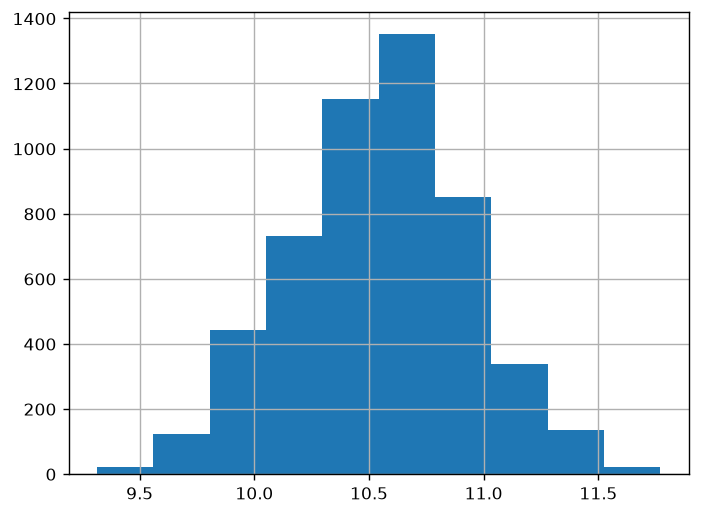

In [103]:
import numpy as np

df_college2["Log Earnings"] = np.log(df_college2["Median Earnings"])
df_college2["Log Earnings"].hist()

6\. The mean gives every college equal weight. But some colleges are tiny (e.g., San Francisco Conservatory, with 228 undergraduates), while others are large (e.g., Penn State, with 72229 undergraduates!).

If we are interested in what *students* earn, we might want to give more weight to colleges with more students. To do this, we can calculate a **weighted mean**:

$$ \sum_{i=1}^n w_i x_i. $$

In general, the weights $w_1, w_2, ..., w_n$ should all be non-negative and should add up to $1.0$. (For the usual mean, every observation gets equal weight, $1/n$.)

Calculate a weighted mean of earnings, using the undergraduate enrollments as weights. Do this by first adding a "weight" column to the data set (number of undegraduates for the college divided by the total number of undergraduates in the data set).

In [104]:
df_college2["weight"] = (
    df_college2["Undergraduates"] / df_college2["Undergraduates"].sum()
)

weighted_mean = (
    df_college2["Median Earnings"] * df_college2["weight"]
).sum()

weighted_mean

np.float64(50608.33831282287)

7\. Compute the mean of earnings for each state. Sort the states in descending order of mean earnings. Display the results in a bar chart.

In [105]:
mean_by_state = (
    df_college2.groupby("State")["Median Earnings"]
    .mean()
    .sort_values(ascending=False)
)

mean_by_state

State
MA    56633.768519
VT    53040.230769
RI    52605.947368
DC    51325.470588
CT    50771.413793
NH    49322.333333
NY    48752.694352
WA    47733.266667
PA    47607.290210
MN    45855.938776
NJ    44964.081081
CA    44461.812371
MD    44454.342857
NE    43776.868421
AK    43604.500000
WI    43417.909091
ME    43400.032258
IN    43311.268519
IL    42443.338624
HI    42162.437500
OR    41934.816667
IA    41809.521127
VA    41803.976744
MO    41702.425197
CO    41578.523077
KS    41244.690141
NV    41184.741935
SD    41136.608696
AZ    40854.298851
DE    40319.153846
OH    40115.951613
ND    39603.080000
VI    39307.000000
WY    38966.300000
GA    38845.460526
AL    38225.338028
TX    38074.490683
MI    37855.232394
MT    37653.480000
NC    37178.948387
NM    36994.588235
TN    36866.411290
SC    36446.682927
FL    36162.099668
UT    35862.604651
WV    35782.507937
OK    35564.678161
KY    35171.828571
MH    34483.000000
LA    34087.642857
AR    32972.202703
ID    32823.666667
MS    

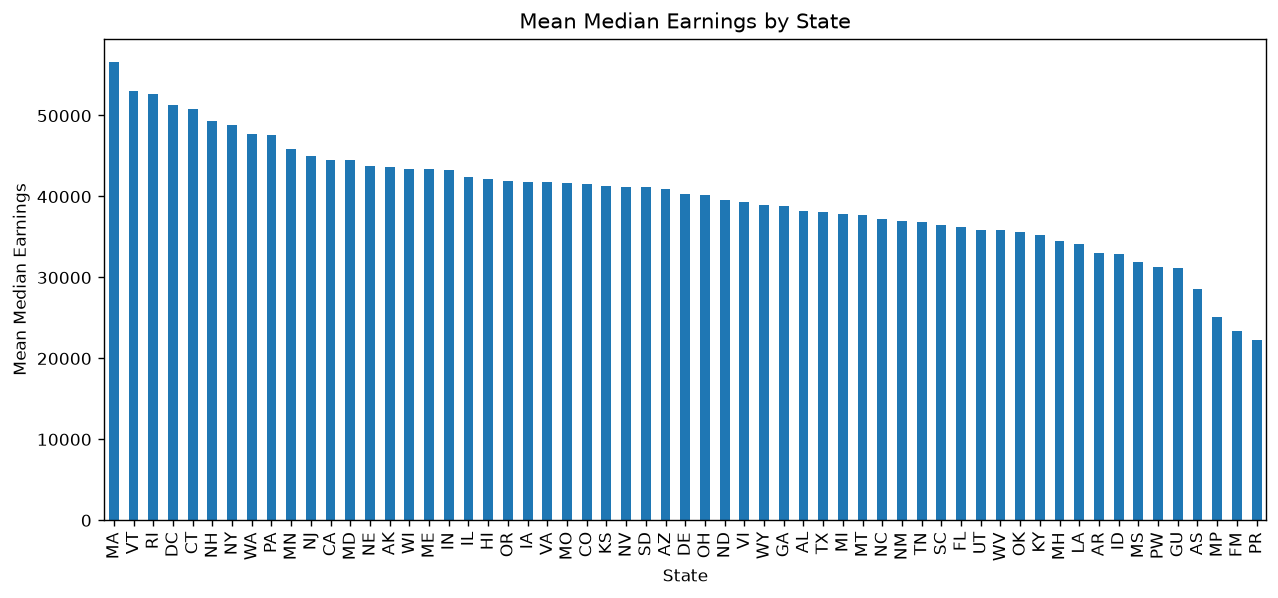

In [106]:
import matplotlib.pyplot as plt

mean_by_state.plot(kind="bar", figsize=(12, 5))

plt.title("Mean Median Earnings by State")
plt.xlabel("State")
plt.ylabel("Mean Median Earnings")
plt.show()

8\. Repeat the previous part, but now compute a weighted mean of earnings for each state, using the number of undegraduate enrollments in the state as weights. (Hint: use `groupby` with `transform`.)

In [107]:
df_college2["state_weight"] = (
    df_college2["Undergraduates"]
    / df_college2.groupby("State")["Undergraduates"].transform("sum")
)

weighted_mean_by_state = (
    df_college2.assign(
        weighted_earnings=df_college2["Median Earnings"] * df_college2["state_weight"]
    )
    .groupby("State")["weighted_earnings"]
    .sum()
    .sort_values(ascending=False)
)

weighted_mean_by_state

State
DC    69939.367698
MA    65365.038613
RI    61382.901051
VT    58815.822129
CT    58515.071887
PA    58152.366783
NY    57869.188381
DE    56136.291687
MD    56049.152616
WA    55332.820949
NH    55043.032070
NJ    54956.421801
UT    54274.369021
ND    53733.319895
VA    53265.020364
MN    53257.575881
WI    52622.024037
IL    52567.618773
CA    51861.217937
IA    51723.723529
NE    51268.810074
CO    50724.480712
OR    50632.035920
IN    50227.922229
MI    50057.879324
WV    50012.392262
MO    49111.791894
TX    48719.078342
ID    48550.410338
HI    48235.746445
AK    47484.939237
SD    47463.984742
GA    47246.144980
KS    47195.607294
ME    47025.392744
NV    46974.859922
FL    46868.957171
OH    46457.828084
SC    46361.251566
AZ    46269.729336
MT    46245.688158
AL    46235.575067
WY    45676.820836
NC    45554.928093
OK    45200.927650
TN    44455.268088
LA    43624.414206
KY    42942.305706
AR    42616.774237
VI    39307.000000
MS    38593.953921
NM    38089.932224
MH    

## Olympic Men's Gymnastics Data



The file https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv contains scores from the qualification and final rounds of the Olympic men's gymnastics all around competition from 2008 to 2020. (Thanks to Martin Hsu for scraping this data set.)

In [108]:
df_gym = pd.read_csv("https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv")

df_gym

,Pos,Gymnast,NOC,Points,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse,Round,Year
0,1.0,Danell Leyva,USA,91.265,15.100,15.500,15.333,15.866,14.600,14.866,Qualification,2012
1,2.0,David Belyavsky,RUS,90.832,15.100,16.300,15.300,14.866,14.366,14.900,Qualification,2012
2,3.0,Fabian HambÃ¼chen,GER,90.765,15.133,15.833,15.300,15.633,14.766,14.100,Qualification,2012
3,4.0,John Orozco,USA,90.597,15.166,15.800,14.533,15.266,15.066,14.766,Qualification,2012
4,5.0,Kristian Thomas,GBR,90.256,15.366,16.200,14.625,15.366,14.566,14.133,Qualification,2012
...,...,...,...,...,...,...,...,...,...,...,...,...
346,20.0,Daniel Keatings,GBR,89.000,14.850,15.800,14.425,14.225,14.000,15.700,Final,2008
347,21.0,Thomas Bouhail,FRA,87.000,15.200,15.850,14.425,14.475,13.650,13.400,Final,2008
348,22.0,José Luis Fuentes,VEN,86.300,14.175,15.250,15.175,14.150,13.900,13.650,Final,2008
349,23.0,Dzmitry Savitski,BLR,82.175,13.725,15.900,13.400,10.100,15.300,13.750,Final,2008


1\. Create a data frame

- With [Round, Year, Gymnast] as the (multi) index, and
- Containing only the six columns with the event scores, "Floor Exercise" through "Pommelled Horse"

In [109]:
events = [
    "Floor Exercise",
    "Horse Vault",
    "Parallel Bars",
    "Horizontal Bar",
    "Rings",
    "Pommelled Horse"
]
gym_scores = df_gym.set_index(["Round", "Year", "Gymnast"])[events].copy()

gym_scores

Floor Exercise  Horse Vault  Parallel Bars  Horizontal Bar   Rings  Pommelled Horse
Round         Year Gymnast                                                                                               
Qualification 2012 Danell Leyva               15.100       15.500         15.333          15.866  14.600           14.866
                   David Belyavsky            15.100       16.300         15.300          14.866  14.366           14.900
                   Fabian HambÃ¼chen          15.133       15.833         15.300          15.633  14.766           14.100
                   John Orozco                15.166       15.800         14.533          15.266  15.066           14.766
                   Kristian Thomas            15.366       16.200         14.625          15.366  14.566           14.133
...                                              ...          ...            ...             ...     ...              ...
Final         2008 Daniel Keatings            14.850       15.800         14.425          14.225  14.000           15.700
                   Thomas Bouhail             15.200       15.850         14.425          14.475  13.650           13.400
                   José Luis Fuentes          14.175       15.250         15.175          14.150  13.900           13.650
                   Dzmitry Savitski           13.725       15.900         13.400          10.100  15.300           13.750
                   Chen Yibing                   NaN       15.900         14.950          12.975  16.650           13.750

[351 rows x 6 columns]

2\. Summarize the scores for each of the six events, by finding the sample size, mean, SD, and *five number summary* (minimum, 25th percentile, median, 75th percentile, maximum). Hint: you can do all this with a single command!

In [110]:
gym_scores.describe()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
count,324.000000,323.000000,323.000000,324.000000,318.000000,325.000000
mean,14.309133,14.976551,14.719288,14.082562,14.237799,13.816723
std,1.254009,0.959876,0.920044,1.299542,0.914523,1.242348
min,1.633000,11.766000,10.200000,0.000000,7.700000,0.000000
25%,13.866000,14.300000,14.233000,13.475000,13.700000,13.266000
50%,14.500000,15.058000,14.900000,14.300000,14.275000,13.925000
75%,15.033000,15.700000,15.350000,14.854000,14.831000,14.566000
max,15.950000,16.775000,16.425000,16.200000,16.650000,16.000000


3\. There are 351 rows in the data frame. Why are the sample sizes different for each event, and not all equal to 351?

**The sample sizes are different because some gymnasts did not compete in every event. Their score for that event is missing, so it is not counted in that event's sample size.**

4\. In the all around competition, each gymnast competes all six events, but this doesn't always happen (due to injury, etc). Therefore, there are some missing values in the data. Most of the missing values are coded as `NaN` but some are coded as 0. What would be a more appropriate way to code the missing values in this case: `NaN` or 0? Why?

**NaN would be more appropriate. A score of 0 is a real score, but NaN indicates that the gymnanst did not compete or their score is unavailable. Using 0 would lower the mean and other values.**

5\. Replace all scores of 0 in the data frame with `NaN`. (Note: It is possible to actually score a 0 on some events, e.g., if you do a vault but don't land feet first. But the few 0s in this data set are for people who didn't compete the event at all.)

In [111]:
gym_scores = gym_scores.replace(0, np.nan)

gym_scores

Floor Exercise  Horse Vault  Parallel Bars  Horizontal Bar   Rings  Pommelled Horse
Round         Year Gymnast                                                                                               
Qualification 2012 Danell Leyva               15.100       15.500         15.333          15.866  14.600           14.866
                   David Belyavsky            15.100       16.300         15.300          14.866  14.366           14.900
                   Fabian HambÃ¼chen          15.133       15.833         15.300          15.633  14.766           14.100
                   John Orozco                15.166       15.800         14.533          15.266  15.066           14.766
                   Kristian Thomas            15.366       16.200         14.625          15.366  14.566           14.133
...                                              ...          ...            ...             ...     ...              ...
Final         2008 Daniel Keatings            14.850       15.800         14.425          14.225  14.000           15.700
                   Thomas Bouhail             15.200       15.850         14.425          14.475  13.650           13.400
                   José Luis Fuentes          14.175       15.250         15.175          14.150  13.900           13.650
                   Dzmitry Savitski           13.725       15.900         13.400          10.100  15.300           13.750
                   Chen Yibing                   NaN       15.900         14.950          12.975  16.650           13.750

[351 rows x 6 columns]

6\. Summarize the revised data. Which events tend to have the highest scores? The lowest? Which events have the greatest degree of variability in scores? The least?

In [112]:
summary = gym_scores.describe().T
summary

print("Highest average score:", summary["mean"].idxmax())
print("Lowest average score:", summary["mean"].idxmin())
print("Greatest variability:", summary["std"].idxmax())
print("Least variability:", summary["std"].idxmin())

Highest average score: Horse Vault
Lowest average score: Pommelled Horse
Greatest variability: Floor Exercise
Least variability: Rings


7\. Compute the correlation matrix. For which pairs of events is the correlation the highest? The lowest?

In [113]:
correlation_matrix = gym_scores.corr()
correlation_matrix

# Keeps only one copy of each event pair and removes the diagonal 1.0 values
pairs = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
).stack()

print("Highest correlation:", pairs.idxmax(), pairs.max())
print("Lowest correlation:", pairs.idxmin(), pairs.min())

Highest correlation: ('Horse Vault', 'Rings') 0.595004531723135
Lowest correlation: ('Floor Exercise', 'Pommelled Horse') 0.2893847180968129


8\. Standardize the scores for each of the six events by subtracting the mean for the event and dividing by its standard deviation. Note: you can do this for all six events at once. You should NOT write a for loop or create a separate line of code for each event.

In [114]:
z_scores = (gym_scores - gym_scores.mean()) / gym_scores.std()

z_scores

Floor Exercise  Horse Vault  Parallel Bars  Horizontal Bar     Rings  Pommelled Horse
Round         Year Gymnast                                                                                                 
Qualification 2012 Danell Leyva             0.630671     0.545330       0.667047        1.677073  0.396055         1.029884
                   David Belyavsky          0.630671     1.378771       0.631179        0.713149  0.140184         1.064669
                   Fabian HambÃ¼chen        0.656987     0.892250       0.631179        1.452479  0.577570         0.246191
                   John Orozco              0.683303     0.857870      -0.202477        1.098718  0.905610         0.927574
                   Kristian Thomas          0.842791     1.274591      -0.102482        1.195111  0.358877         0.279953
...                                              ...          ...            ...             ...       ...              ...
Final         2008 Daniel Keatings          0.431311     0.857870      -0.319863        0.095273 -0.260025         1.883148
                   Thomas Bouhail           0.710416     0.909960      -0.319863        0.336254 -0.642738        -0.469978
                   José Luis Fuentes       -0.106963     0.284879       0.495316        0.022979 -0.369372        -0.214203
                   Dzmitry Savitski        -0.465812     0.962050      -1.433940       -3.880914  1.161481        -0.111893
                   Chen Yibing                   NaN     0.962050       0.250762       -1.109632  2.637661        -0.111893

[351 rows x 6 columns]

9\. The all around champion is whoever has the highest total score for the six events (in the finals). But who is the "all around standardized value champion"? Create a column that sums the standardized values for each athlete, then sort the data frame in descending order by that column. Note: you should NOT have to manually add six columns.

In [115]:
standardized_totals = z_scores.sum(axis=1).sort_values(ascending=False)

standardized_totals

Round          Year  Gymnast         
Final          2008  Yang Wei             8.574298
Qualification  2008  Yang Wei             7.739403
Final          2012  Kohei Uchimura       6.485111
Qualification  2008  Kim Dae-Eun          6.206298
                     Li Xiaopeng          6.200877
                                           ...    
               2020  Uche Eke           -11.591600
                     David Huddleston   -11.919628
                     Hung Yuan-Hsi      -12.456954
                     David Rumbutis     -13.635800
                     Jeremiah Loo       -19.545795
Length: 351, dtype: float64

10\. Compute the mean score for each event in each year. How do the means change over time? Why do you think this happened?

In [116]:
mean_scores_by_year = gym_scores.groupby(level="Year").mean()

mean_scores_by_year

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
Year,,,,,,
2008,14.720250,15.841753,15.125758,14.563750,14.850532,14.248750
2012,14.495154,15.484308,14.663231,14.365922,14.441462,13.787172
2016,14.134667,14.496068,14.787083,14.246315,14.201514,14.051319
2020,13.841989,14.046398,14.242529,13.336919,13.453632,13.312341


11\. Choose one event and for that event create a plot with a single panel that summarizes the distribution of scores for each of the four years. Describe what you see.

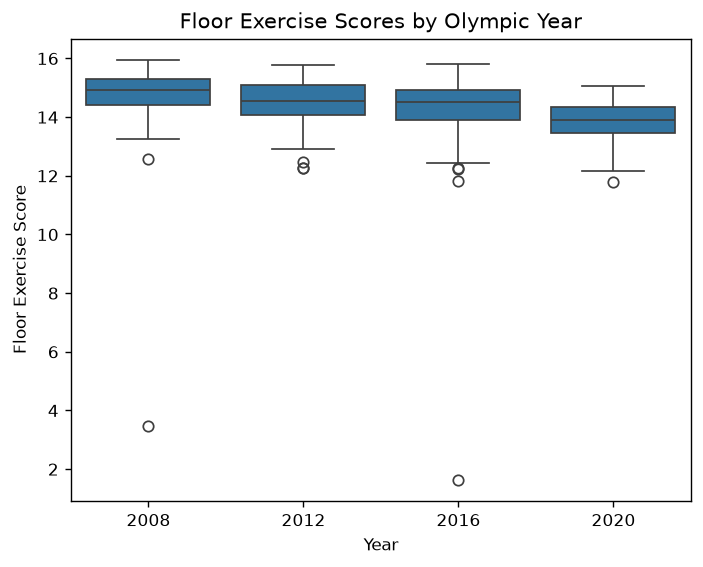

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_data = gym_scores.reset_index()

sns.boxplot(data=plot_data, x="Year", y="Floor Exercise")

plt.title("Floor Exercise Scores by Olympic Year")
plt.xlabel("Year")
plt.ylabel("Floor Exercise Score")
plt.show()

12\. Standardize the scores for each of the six events by subtracting the mean for the event and dividing by its standard deviation *within each year*. Note: you can do this for all six events at once. You should NOT write a for loop or create a separate line of code for each event.


In [118]:
year_means = gym_scores.groupby(level="Year").transform("mean")
year_sds = gym_scores.groupby(level="Year").transform("std")

z_scores_within_year = (gym_scores - year_means) / year_sds

z_scores_within_year

Floor Exercise  Horse Vault  Parallel Bars  Horizontal Bar     Rings  Pommelled Horse
Round         Year Gymnast                                                                                                 
Qualification 2012 Danell Leyva             0.753096     0.027915       1.002995        1.708332  0.269011         1.232874
                   David Belyavsky          0.753096     1.451057       0.953577        0.569503 -0.128045         1.271729
                   Fabian HambÃ¼chen        0.794185     0.620298       0.953577        1.442985  0.550683         0.357497
                   John Orozco              0.835273     0.561594      -0.195024        1.025035  1.059729         1.118595
                   Kristian Thomas          1.084294     1.273164      -0.057251        1.138917  0.211319         0.395209
...                                              ...          ...            ...             ...       ...              ...
Final         2008 Daniel Keatings          0.098864    -0.076907      -0.896615       -0.385333 -1.098537         1.745577
                   Thomas Bouhail           0.365547     0.015192      -0.896615       -0.100954 -1.550593        -1.020884
                   José Luis Fuentes       -0.415455    -1.089993       0.063005       -0.470647 -1.227696        -0.720182
                   Dzmitry Savitski        -0.758335     0.107290      -2.208096       -5.077583  0.580528        -0.599901
                   Chen Yibing                   NaN     0.107290      -0.224881       -1.807227  2.324171        -0.599901

[351 rows x 6 columns]

13\. If we standardize within each year, which athletes (and rounds and year) had the highest total standardized values? Basically repeat part 9 but with standardization within each year.

In [119]:
within_year_totals = (
    z_scores_within_year
    .sum(axis=1)
    .sort_values(ascending=False)
)

within_year_totals

Round          Year  Gymnast        
Final          2016  Oleh Verniaiev      7.614139
               2012  Kohei Uchimura      7.514300
Qualification  2020  Daiki Hashimoto     7.393287
Final          2020  Daiki Hashimoto     7.245313
Qualification  2016  Oleh Verniaiev      7.110561
                                          ...    
               2008  Mohamed Srour      -9.949575
               2020  David Rumbutis    -10.920078
               2016  KÃ©vin Crovetto   -11.442155
               2008  Brandon O'Neill   -12.283942
               2020  Jeremiah Loo      -16.509494
Length: 351, dtype: float64